# AquaPredict - Sistema inteligente para reservatórios de água

Universidade Federal Rural do Semi-Árido (UFERSA) <br>
Disciplina: Sistemas Inteligentes <br>
Docente: Pedro Thiago Valério de Souza <br>

Autores: <br>
Alex Bruno Duarte | alex.duarte@alunos.ufersa.edu.br | <a href="https://github.com/alexb7z" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
Carlos Henrique de Queiroz | carlos.queiroz53447@alunos.ufersa.edu.br | <a href="https://github.com/CarlossQueiroz" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
José Veríssimo de Oliveira Queiroz | jose.queiroz58390@alunos.ufersa.edu.br | <a href="https://github.com/JV-ANUBIS" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
Thallys Araújo de Morais | thallys.araujo@alunos.ufersa.edu.br | <a href="https://github.com/ThallysAM" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br> <br>


## 1. Introdução
---

O gerenciamento eficiente de reservatórios de água é um desafio crítico, especialmente em regiões semiáridas como o Nordeste brasileiro. Sistemas convencionais operam de forma **reativa**: bombas e válvulas são acionadas apenas após a detecção de níveis críticos, o que frequentemente resulta em desperdício de energia, desgaste prematuro dos equipamentos e risco de desabastecimento.

A adoção de uma abordagem **preditiva**, capaz de antecipar o comportamento do consumo com base em padrões históricos e variáveis climáticas, representa uma alternativa mais eficiente e inteligente para o controle desses sistemas.


### 1.1. Objetivo
---

Este projeto tem como objetivo desenvolver o **AquaPredict**, um sistema inteligente capaz de:

- **Prever o consumo de água** para a próxima hora com base em dados históricos
- **Estimar o tempo** até o reservatório atingir nível crítico
- **Recomendar o acionamento antecipado** da bomba, evitando desabastecimento

Para isso, é implementada uma **Rede Neural MLP (Multilayer Perceptron)**, cujo desempenho é comparado a um modelo de **Regressão Linear** utilizado como baseline, permitindo avaliar o ganho real obtido com o uso de uma abordagem não-linear.

## 2. Conjunto de dados
---

Para o desenvolvimento desta etapa do trabalho, foi utilizado o conjunto de dados "SOWEKI Water Demand Dataset", disponibilizado publicamente no repositório Zenodo pelos pesquisadores Felix Sehmer, Maximilian Hoffmann, Norberth Kloos e Ralph Bergmann (publicado em abril de 2026).

Diferente do conjunto anterior, este dataset contém medições contínuas com uma granularidade mais alta, registrando a demanda e os níveis hídricos em intervalos de 15 minutos. O objetivo principal da utilização desta base é permitir o desenvolvimento de modelos preditivos de curtíssimo prazo, capazes de antecipar quedas de nível e auxiliar no acionamento imediato e inteligente da operação de bombas em reservatórios.

Neste projeto foi utilizado o arquivo "soweki_wdd_1.csv", estruturado em formato de série temporal. Para que a Rede Neural pudesse aprender o comportamento do sistema, os dados brutos passaram por uma engenharia de features.

As principais variáveis presentes e construídas no modelo são:

- **timestamp**: data e horário exato da observação, da qual foram extraídas as sazonalidades (Hora, Minuto e Dia da Semana);

- **value**: valor contínuo registrado para a demanda/nível de água no respectivo intervalo de 15 minutos;

- **Lags (Lag1 a Lag4)**: variáveis de histórico (memória) criadas no pré-processamento. Elas representam as últimas quatro leituras do sensor, permitindo que o modelo compreenda o comportamento da água na última 1 hora;

- **Target**: a variável alvo do modelo, configurada para prever o estado do sistema 1 hora à frente (4 intervalos no futuro).

## 3. Pré-processamento
---

Importação das bibliotecas

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Carregamento dos dados

In [77]:
# URL do dataset bruto no repositório
url = "https://raw.githubusercontent.com/alexb7z/aqua-predict/main/data/m2/soweki_wdd_1.csv"

# Carrega os dados em um DataFrame do Pandas
df = pd.read_csv(url)

# Exibe as 5 primeiras linhas para conferência rápida
df.head()

,timestamp,value
0,2024-09-06T22:00:00+00:00,2.911446
1,2024-09-06T22:15:00+00:00,2.764983
2,2024-09-06T22:30:00+00:00,2.903234
3,2024-09-06T22:45:00+00:00,2.134375
4,2024-09-06T23:00:00+00:00,1.929706


Pré-precssamento dos dados

In [78]:
# Converte a coluna de timestamp (string) para o tipo datetime do Pandas
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extrai features temporais para o modelo entender a sazonalidade diária e em minutos
df["Hour"] = df["timestamp"].dt.hour
df["Minute"] = df["timestamp"].dt.minute
df["DayOfWeek"] = df["timestamp"].dt.dayofweek

# Cria as features de atraso (Lags): leituras anteriores em intervalos de 15 minutos
df["Lag1"] = df["value"].shift(1)   # 15 min atrás
df["Lag2"] = df["value"].shift(2)   # 30 min atrás
df["Lag3"] = df["value"].shift(3)   # 45 min atrás
df["Lag4"] = df["value"].shift(4)   # 60 min atrás

# Cria a variável alvo (Target): O valor que queremos prever daqui a 1 hora (4 passos de 15 min)
df["Target"] = df["value"].shift(-4)

# Remove as linhas com valores nulos gerados pelos comandos 'shift'
df = df.dropna()

# Filtra e reordena o DataFrame para manter apenas as colunas úteis para o modelo
df = df[
    [
        "Hour",
        "Minute",
        "DayOfWeek",
        "Lag1",
        "Lag2",
        "Lag3",
        "Lag4",
        "Target"
    ]
]

# Exibe o dataset pronto para a modelagem
df.head()

,Hour,Minute,DayOfWeek,Lag1,Lag2,Lag3,Lag4,Target
4,23,0,4,2.134375,2.903234,2.764983,2.911446,2.032708
5,23,15,4,1.929706,2.134375,2.903234,2.764983,1.749732
6,23,30,4,1.757241,1.929706,2.134375,2.903234,1.877401
7,23,45,4,1.957656,1.757241,1.929706,2.134375,1.640061
8,0,0,5,1.814308,1.957656,1.757241,1.929706,1.371196


Definição das features e target

In [79]:
# X contém apenas as variáveis preditivas (recursos temporais e lags históricos)
X = df[
    [
        "Hour",
        "Minute",
        "DayOfWeek",
        "Lag1",
        "Lag2",
        "Lag3",
        "Lag4"
    ]
]

# y contém a variável que queremos prever (o valor futuro)
y = df["Target"]

Padronização dos dados

In [80]:
# Inicializa o padronizador (remove a média e escala para variância unitária)
scaler = StandardScaler()

# Ajusta o scaler aos dados e já transforma o conjunto X
X_scaled = scaler.fit_transform(X)

Divisão treino/teste

In [81]:
# Separa 80% dos dados para treinar o modelo e 20% para testar.
# shuffle=False é FUNDAMENTAL aqui porque são dados temporais.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    shuffle=False
)

## 4. Implementação da MLP
---

In [82]:
# Instancia o Regressor Multi-Layer Perceptron (Rede Neural para valores contínuos)
mlp = MLPRegressor(
    # Define a arquitetura da rede: duas camadas ocultas, com 64 e 32 neurônios
    hidden_layer_sizes=(64, 32),

    # Função de ativação ReLU para capturar padrões não-lineares
    activation="relu",

    # Número máximo de iterações configurado para 1000 para garantir a convergência neste dataset
    max_iter=1000,

    # Define uma semente aleatória para garantir a reprodutibilidade
    random_state=42
)

# Treina o modelo usando os dados de treino (features X e gabarito y)
mlp.fit(X_train, y_train)

# Previsão com dados de teste
# Usa o modelo treinado para prever os valores futuros com base nos dados de teste
y_pred = mlp.predict(X_test)

## 5. Implementação da Regressão Linear
---

In [83]:
# Instancia o modelo de Regressão Linear (Modelo Baseline)
lr = LinearRegression()

# Treina o modelo com os dados de treino
lr.fit(X_train, y_train)

# Realiza as previsões com os dados de teste (já no mesmo bloco para agilizar)
y_pred_lr = lr.predict(X_test)

## 6. Avaliação do modelo
---

Métricas do MLP

In [84]:
# MAE (Mean Absolute Error): Erro médio absoluto. Mostra o desvio médio das previsões.
mae = mean_absolute_error(y_test, y_pred)

# RMSE (Root Mean Squared Error): Raiz do erro quadrático médio. Penaliza mais fortemente os erros grandes.
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# R² (R-Squared): Coeficiente de determinação. Mostra a qualidade do ajuste do modelo.
r2 = r2_score(y_test, y_pred)

print("--- Métricas do MLP ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

--- Métricas do MLP ---
MAE:  0.84
RMSE: 1.11
R²:   0.7880


Gráficos de consumo real x consumo previsto do MLP

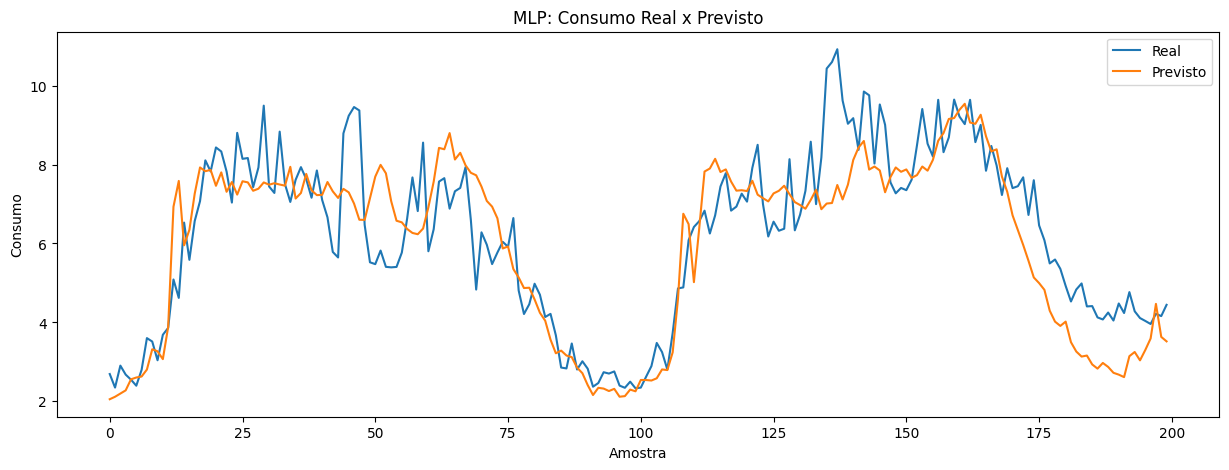

In [85]:
# --- Gráfico de Linha: Comportamento ao longo do tempo ---
plt.figure(figsize=(15, 5))

# Plota os primeiros 200 registros reais (usamos .values para padronizar o alinhamento)
plt.plot(y_test.values[:200], label="Real")

# Plota as primeiras 200 previsões do MLP
plt.plot(y_pred[:200], label="Previsto")

plt.title("MLP: Consumo Real x Previsto")
plt.xlabel("Amostra")
plt.ylabel("Consumo")
plt.legend()
plt.show() # Renderiza o primeiro gráfico

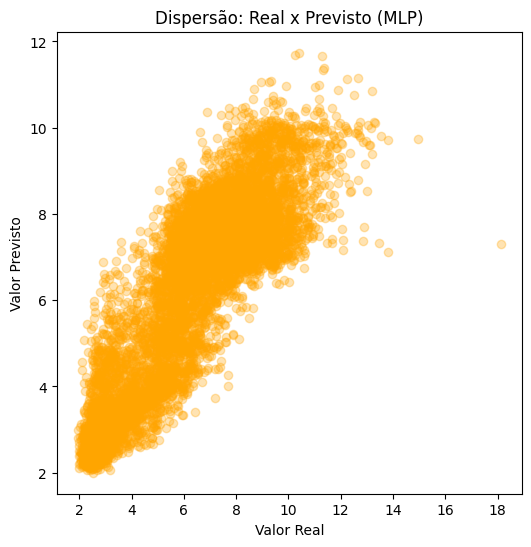

In [86]:
# --- Gráfico de Dispersão (Scatter): Correlação Real vs Previsto ---
plt.figure(figsize=(6, 6))

# O alpha=0.3 deixa os pontos transparentes para evidenciar a densidade das previsões
plt.scatter(y_test, y_pred, alpha=0.3, color="orange")

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Dispersão: Real x Previsto (MLP)")
plt.show() # Renderiza o segundo gráfico

Métricas da Regressão Linear

In [87]:
# Calcula as métricas para o modelo de Regressão Linear
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Métricas da Regressão Linear (Baseline) ---")
print(f"MAE:  {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²:   {r2_lr:.4f}")

--- Métricas da Regressão Linear (Baseline) ---
MAE:  1.15
RMSE: 1.45
R²:   0.6394


Gráficos de consumo real x consumo previsto da Regressão Linear

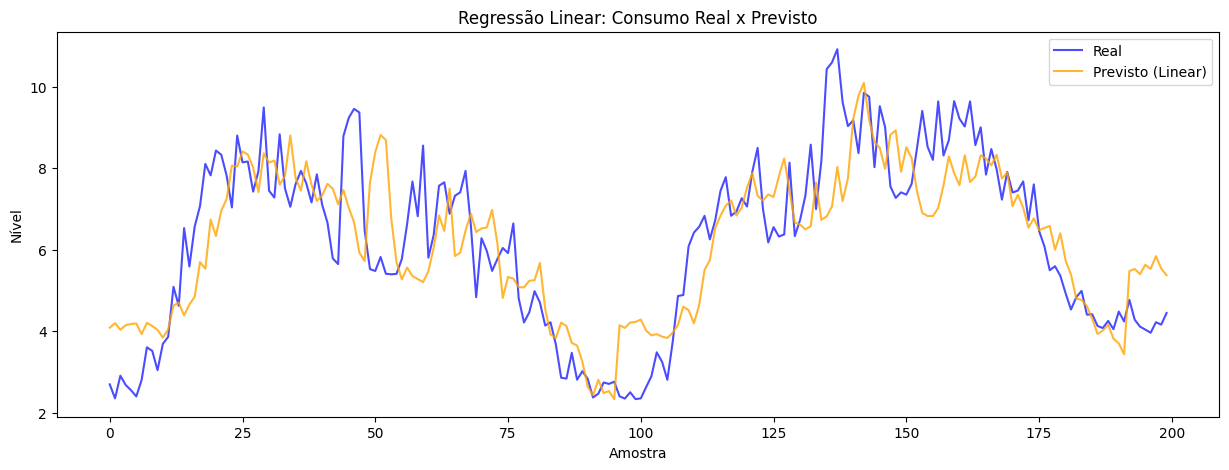

In [88]:
# Gráfico comparativo de linha
plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:200], label="Real", color="blue", alpha=0.7)
plt.plot(y_pred_lr[:200], label="Previsto (Linear)", color="orange", alpha=0.8)

plt.title("Regressão Linear: Consumo Real x Previsto")
plt.xlabel("Amostra")
plt.ylabel("Nível")
plt.legend()
plt.show()

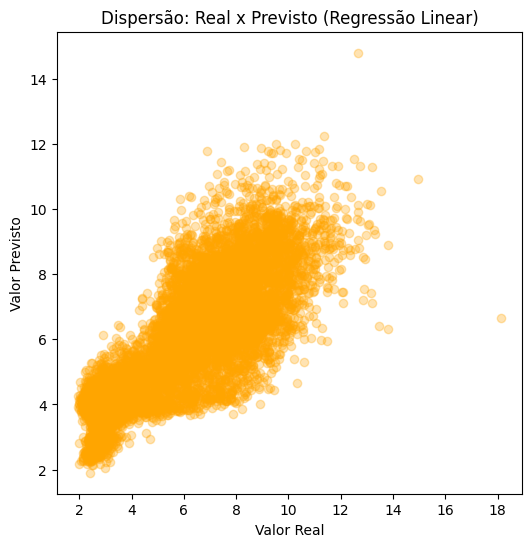

In [89]:
# --- Gráfico de Dispersão (Scatter): Real x Previsto (Regressão Linear) ---
plt.figure(figsize=(6, 6))

# Plota a dispersão usando as previsões da Regressão Linear para comparação visual direta
plt.scatter(y_test, y_pred_lr, alpha=0.3, color="orange")

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Dispersão: Real x Previsto (Regressão Linear)")
plt.show()

## 7. Sistema de recomendação
---

Exemplo do sistema de recomendação de acionamento da bomba

In [90]:
# Nível de água medido no momento atual pelo sensor (ex: vindo do HC-SR04)
nivel_atual = 4.5

# Extrai a previsão do nível de água para daqui a 1 hora usando o último dado disponível
nivel_previsto = mlp.predict(X_test[-1:])[0]

# Define o threshold crítico de segurança para monitoramento do reservatório
nivel_critico = 3.0

print(f"Nível atual: {nivel_atual:.2f}")
print(f"Nível previsto para daqui a 1 hora: {nivel_previsto:.2f}")

# Calcula a taxa de queda por hora
taxa_queda = nivel_atual - nivel_previsto

# Se o nível estiver caindo, calculamos o tempo até atingir o limite crítico
if taxa_queda > 0 and nivel_atual > nivel_critico:
    horas_restantes = (nivel_atual - nivel_critico) / taxa_queda

    # Converte o valor decimal de horas para minutos totais e separa em Horas e Minutos
    total_minutos = round(horas_restantes * 60)
    horas, minutos = divmod(total_minutos, 60)

    print(f"Tempo estimado até atingir o nível crítico: {horas} horas e {minutos} minutos")
else:
    print("O nível está estável ou subindo.")

# Lógica condicional (Trigger): Decide se envia o comando de ativação para a automação física
if nivel_previsto < nivel_critico:
    print("⚠️ ACIONAR BOMBA")
else:
    print("✅ NÍVEL SEGURO")

Nível atual: 4.50
Nível previsto para daqui a 1 hora: 2.85
Tempo estimado até atingir o nível crítico: 0 horas e 55 minutos
⚠️ ACIONAR BOMBA


## 8. Conclusão
---

Alta Precisão na Previsão: Aqui o MLP brilhou ainda mais, alcançando um $R^2$ de 0.7880 (quase 79% de precisão na captura da variância), superando os 63,9% do modelo linear.

Margem de Erro Mínima: O MAE do MLP ficou em impressionantes 0.84 (contra 1.15 do baseline). Na prática, prever o nível da água errando por menos de 1 unidade mostra que o modelo está extremamente bem ajustado aos dados dos sensores.

Interpretação Prática: A estratégia de usar 4 atrasos temporais (Lags equivalentes a 1 hora de histórico) foi perfeita. O modelo aprendeu exatamente como a velocidade de queda ou subida da água se comporta no curto prazo. Com um RMSE de apenas 1.11, fica claro que o modelo quase não comete erros grotescos, o que traz uma segurança enorme para o gatilho automático que decide acionar ou não o relé do sistema.